In [2]:
!pip install pandas numpy matplotlib seaborn

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting for Colab
%matplotlib inline

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (assumes the file is named 'formatting_data.csv')
df = pd.read_csv('formatting_data.csv')

# Convert datetime columns
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['First Interaction Date'] = pd.to_datetime(df['First Interaction Date'], errors='coerce')
df['Last Purchase Date'] = pd.to_datetime(df['Last Purchase Date'], errors='coerce')

print("Dataset loaded successfully!")

Saving formatting_data.csv to formatting_data.csv
Dataset loaded successfully!


**This section explores the dataset's structure, missing values, key summaries, and trends.**

=== Exploratory Data Analysis ===

1. Dataset Overview:
Shape: (3000, 136)
Columns: ['Name', 'Email', 'Location', 'Zip Code', 'Age', 'Gender', 'Language', 'Loyalty Program Member', 'Product Name', 'Purchase History', 'Avg Order Value', 'Cart Abandoned', 'Payment Method', 'Page Views', 'Time Spent (min)', 'Clickstream Data', 'Search Query', 'Bounce Rate', 'Newsletter Opened', 'Product Rating', 'Support Queries', 'Survey Response', 'Social Media Share', 'Device Type', 'Browser Type', 'Operating System', 'IP Address', 'Referral Source', 'Promotional Elasticity', 'Loyalty Effect on Purchase', 'Engagement Score', 'Cost per Acquisition (CPA)', 'Cost per Channel', 'Total Revenue', 'Gross Profit', 'Net Profit', 'COGS', 'Operating Expenses', 'Profit Margin (%)', 'Revenue Trend', 'Expense Breakdown', 'Gross vs Net Profit', 'Region-wise Revenue Contribution', 'Churned', 'Customer ID', 'Transaction Date', 'Previous Category', 'Total Completed Purchase Value', 'Total Orders in Time Slot', 'Total Fl

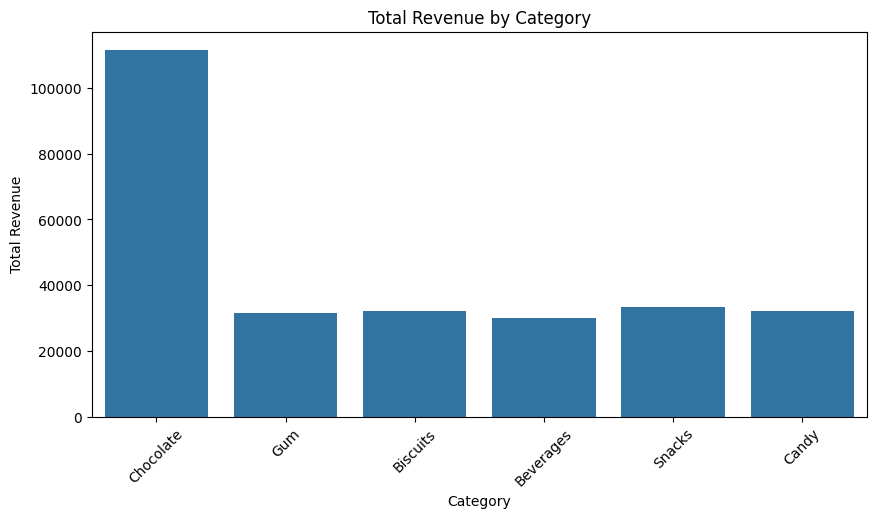

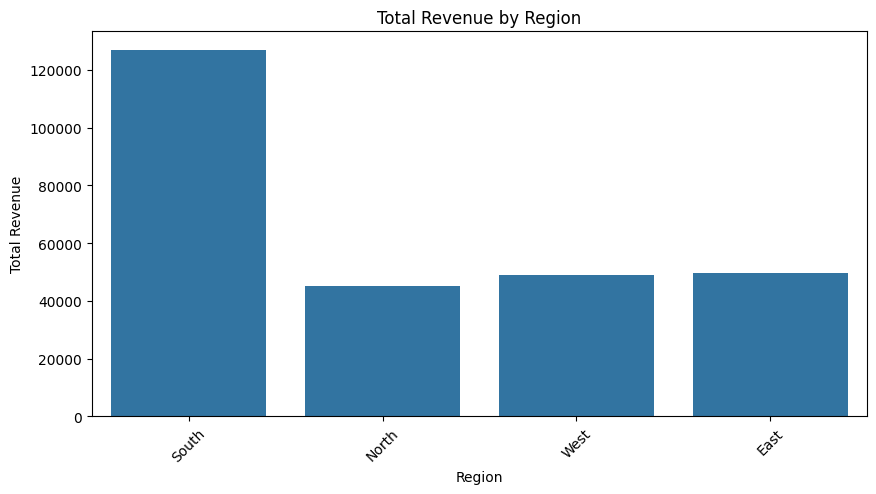


6. Revenue Trend Over Time:


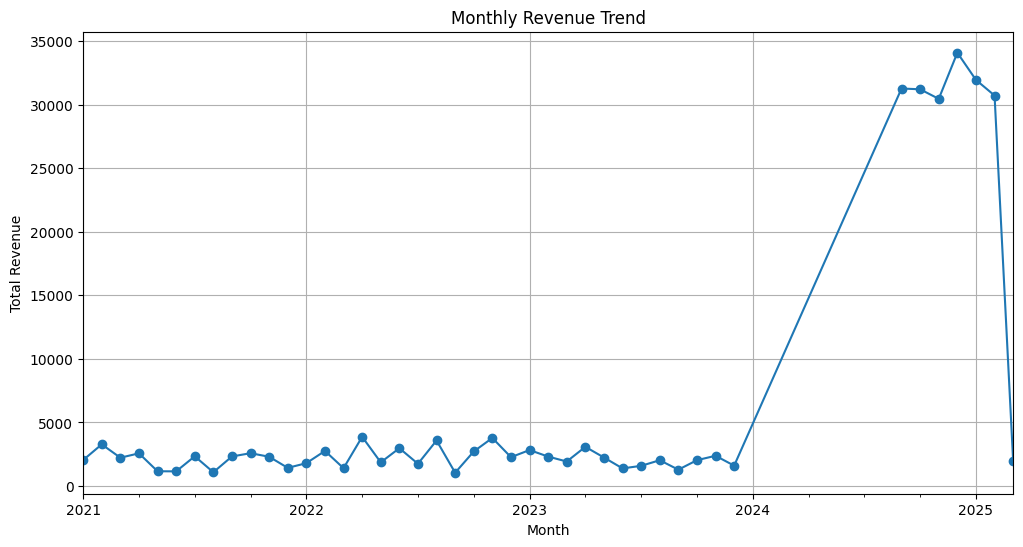


7. Churn and Sentiment Insights:
Overall Churn Rate: 46.30%

Survey Response Distribution:
Survey Response
Negative    2357
Neutral      329
Positive     314
Name: count, dtype: int64


In [4]:
def perform_eda(df):
    print("=== Exploratory Data Analysis ===")

    # 1. Dataset Overview
    print("\n1. Dataset Overview:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Time Range: {df['Transaction Date'].min()} to {df['Transaction Date'].max()}")

    # 2. Missing Values Check
    print("\n2. Missing Values:")
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percentage})
    print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False))

    # 3. Key Numerical Summaries
    print("\n3. Key Numerical Summaries:")
    numerical_cols = ['Quantity Sold', 'Product Price', 'Total Revenue', 'Gross Profit', 'Churned', 'Ad_Clicks', 'Impressions']
    available_numerical_cols = [col for col in numerical_cols if col in df.columns]
    if available_numerical_cols:
        print(df[available_numerical_cols].describe())

    # 4. Categorical Variables Insights
    print("\n4. Categorical Variables Insights:")
    categorical_cols = ['Category', 'Region', 'Channel', 'Customer Segment Type']
    available_categorical_cols = [col for col in categorical_cols if col in df.columns]
    for col in available_categorical_cols:
        print(f"\nTop 5 {col} by Count:")
        print(df[col].value_counts().head())

    # 5. Revenue by Key Dimensions
    print("\n5. Revenue Insights:")
    if 'Total Revenue' in df.columns and 'Category' in df.columns:
        plt.figure(figsize=(10, 5))
        sns.barplot(x='Category', y='Total Revenue', data=df, estimator=sum, errorbar=None)
        plt.title('Total Revenue by Category')
        plt.xticks(rotation=45)
        plt.show()

    if 'Total Revenue' in df.columns and 'Region' in df.columns:
        plt.figure(figsize=(10, 5))
        sns.barplot(x='Region', y='Total Revenue', data=df, estimator=sum, errorbar=None)
        plt.title('Total Revenue by Region')
        plt.xticks(rotation=45)
        plt.show()

    # 6. Time Trend
    if 'Transaction Date' in df.columns and 'Total Revenue' in df.columns:
        print("\n6. Revenue Trend Over Time:")
        df['Month'] = df['Transaction Date'].dt.to_period('M')
        monthly_revenue = df.groupby('Month')['Total Revenue'].sum()
        plt.figure(figsize=(12, 6))
        monthly_revenue.plot(kind='line', marker='o')
        plt.title('Monthly Revenue Trend')
        plt.xlabel('Month')
        plt.ylabel('Total Revenue')
        plt.grid(True)
        plt.show()

    # 7. Churn and Sentiment Insights
    print("\n7. Churn and Sentiment Insights:")
    if 'Churned' in df.columns:
        churn_rate = df['Churned'].mean() * 100
        print(f"Overall Churn Rate: {churn_rate:.2f}%")
    if 'Survey Response' in df.columns:
        sentiment_counts = df['Survey Response'].value_counts()
        print("\nSurvey Response Distribution:")
        print(sentiment_counts)

# Run EDA
perform_eda(df)

# **KPI Calculations**

In [5]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.3 MB/s eta 0:00:00


In [6]:
import kaleido
print(kaleido.__version__)

0.2.1


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import os

def calculate_kpis(df):
    # Create 'charts' folder if it doesn't exist
    if not os.path.exists('charts'):
        os.makedirs('charts')

    # Helper function to check column existence
    def has_columns(*cols):
        return all(col in df.columns for col in cols)

    # Set up plotting style
    sns.set(style="whitegrid")

    # === 1. Executive Summary (Consumer 360) ===
    total_consumers = df['Customer ID'].nunique() if has_columns('Customer ID') else 0

    # Repeat Consumers: Based on 'Customer Segment' or 'Purchase Frequency'
    if has_columns('Customer Segment', 'Customer ID'):
        repeat_segments = ['occasional', 'loyal']
        repeat_consumers = df[df['Customer Segment'].isin(repeat_segments)]['Customer ID'].nunique()
    elif has_columns('Purchase Frequency', 'Customer ID'):
        repeat_consumers = df[df['Purchase Frequency'] > 1]['Customer ID'].nunique()
    elif has_columns('Customer ID', 'Transaction Date'):
        purchase_counts = df.groupby('Customer ID')['Transaction Date'].count()
        repeat_consumers = purchase_counts[purchase_counts > 1].index.nunique()
    else:
        repeat_consumers = 0

    new_consumers = total_consumers - repeat_consumers if total_consumers > 0 else 0

    # New Consumers MoM: First-time buyers in the latest month
    if has_columns('Transaction Date', 'Customer ID'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        latest_month = df['Transaction Date'].dt.to_period('M').max()
        first_purchase = df.groupby('Customer ID')['Transaction Date'].min().dt.to_period('M')
        new_in_latest = (first_purchase == latest_month).sum()
        new_in_prior = (first_purchase == latest_month - 1).sum() if latest_month > first_purchase.min() else 0
        new_consumers_mom = new_in_latest - new_in_prior
    else:
        new_consumers_mom = 0

    repeat_purchase_rate = df['Repeat_Purchase_Rate'].mean() if has_columns('Repeat_Purchase_Rate') else (repeat_consumers / total_consumers * 100) if total_consumers > 0 else 0

    # Total Revenue: Use provided columns if available
    if has_columns('Quantity Sold', 'Price Paid'):
        total_revenue = (df['Quantity Sold'] * df['Price Paid']).sum()
    elif has_columns('Total Revenue'):
        total_revenue = df['Total Revenue'].sum()
    else:
        total_revenue = 0

    total_orders = df['Total Orders in Time Slot'].sum() if has_columns('Total Orders in Time Slot') else 0
    total_units_sold = df['Quantity Sold'].sum() if has_columns('Quantity Sold') else 0
    gross_profit = df['Gross Profit'].sum() if has_columns('Gross Profit') else 0

    # Churn Rate: Use 'Churned' or similar
    if has_columns('Churned'):
        churned = df['Churned'].sum()
    elif has_columns('Churned Status'):
        churned = df[df['Churned Status'] == True]['Customer ID'].nunique()
    elif has_columns('Churn Risk'):
        churned = df[df['Churn Risk'] == 'high']['Customer ID'].nunique()
    else:
        churned = 0
    active = total_consumers - churned if total_consumers > 0 else 0
    churn_rate = (churned / (churned + active) * 100) if (churned + active) > 0 else 0

    aov = df['AOV'].mean() if has_columns('AOV') else (total_revenue / total_orders if total_orders > 0 else 0)
    abs = df['Basket Size'].mean() if has_columns('Basket Size') else (total_units_sold / total_orders if total_orders > 0 else 0)
    purchase_frequency = df['Purchase Frequency'].mean() if has_columns('Purchase Frequency') else (total_orders / total_consumers if total_consumers > 0 else 0)

    gross_margin = (gross_profit / total_revenue * 100) if total_revenue > 0 else 0
    clv = (aov * purchase_frequency * gross_margin) / churn_rate if churn_rate > 0 else 0

    promoters = len(df[df['Survey Response'] == 'Positive']) if has_columns('Survey Response') else 0
    detractors = len(df[df['Survey Response'] == 'Negative']) if has_columns('Survey Response') else 0
    total_responses = len(df) if has_columns('Survey Response') else 0
    nps = ((promoters / total_responses) - (detractors / total_responses)) * 100 if total_responses > 0 else 0

    # Graphs
    if has_columns('Channel', 'Total Revenue'):
        channel_revenue = df.groupby('Channel')['Total Revenue'].sum()
        plt.figure(figsize=(8, 6))
        plt.pie(channel_revenue, labels=channel_revenue.index, autopct='%1.1f%%', startangle=90)
        plt.title('Channel Preference')
        plt.savefig('charts/channel_preference_pie.png')
        plt.close()

    if has_columns('Customer Segment Type', 'Customer ID'):
        seg_counts = df.groupby('Customer Segment Type')['Customer ID'].nunique()
        seg_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title('Consumer Segmentation')
        plt.xlabel('Segment Type')
        plt.ylabel('Number of Consumers')
        plt.savefig('charts/consumer_segmentation_stacked_bar.png')
        plt.close()

    if has_columns('Transaction Date', 'Total Orders in Time Slot'):
        purchase_trend = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Orders in Time Slot'].sum()
        plt.figure(figsize=(10, 6))
        purchase_trend.plot(kind='line')
        plt.title('Purchase Frequency Trend')
        plt.xlabel('Month')
        plt.ylabel('Total Orders')
        plt.savefig('charts/purchase_frequency_trend_line.png')
        plt.close()

    if has_columns('Delivery Location Country', 'Customer ID'):
        geo_dist = df.groupby('Delivery Location Country')['Customer ID'].nunique()
        plt.figure(figsize=(10, 6))
        geo_dist.plot(kind='bar')
        plt.title('Geo-wise Consumer Distribution')
        plt.xlabel('Location')
        plt.ylabel('Number of Consumers')
        plt.savefig('charts/geo_distribution_bar.png')
        plt.close()
    elif has_columns('Location', 'Customer ID'):  # Fallback if 'Delivery Location Country' is unavailable
        geo_dist = df.groupby('Location')['Customer ID'].nunique()
        plt.figure(figsize=(10, 6))
        geo_dist.plot(kind='bar')
        plt.title('Geo-wise Consumer Distribution')
        plt.xlabel('Location')
        plt.ylabel('Number of Consumers')
        plt.savefig('charts/geo_distribution_bar.png')
        plt.close()

    # === 2. Category Summary ===
    # Category Revenue: Adjusted for refunds if available
    if has_columns('Quantity Sold', 'Price Paid'):
        df['Category Revenue'] = df['Quantity Sold'] * df['Price Paid']
        if has_columns('Rate of Refund'):
            df['Category Revenue'] *= (1 - df['Rate of Refund'] / 100)
    elif has_columns('Total Revenue'):
        df['Category Revenue'] = df['Total Revenue']
    else:
        df['Category Revenue'] = 0

    category_revenue = df.groupby('Category')['Category Revenue'].sum()
    top_category = category_revenue.idxmax() if not category_revenue.empty else "N/A"

    # Category Growth: Monthly sales growth rate
    if has_columns('Category', 'Transaction Date', 'Category Revenue'):
        monthly_sales = df.groupby(['Category', df['Transaction Date'].dt.to_period('M')])['Category Revenue'].sum().unstack(level=0)
        category_growth = monthly_sales.pct_change().fillna(0) * 100
        category_highest_growth = category_growth.mean().idxmax() if not category_growth.empty else "N/A"  # Average growth across months
    else:
        category_highest_growth = "N/A"

    # Most Purchased Product in Category
    if has_columns('Category', 'Product Name', 'Quantity Sold'):
        most_purchased_product = df.groupby(['Category', 'Product Name'])['Quantity Sold'].sum().idxmax()
    elif has_columns('Category', 'Product Name', 'Quantity_Purchased'):
        most_purchased_product = df.groupby(['Category', 'Product Name'])['Quantity_Purchased'].sum().idxmax()
    else:
        most_purchased_product = ("N/A", "N/A")

    total_revenue = df['Category Revenue'].sum() if has_columns('Category Revenue') else 0
    category_orders = df.groupby('Category')['Total Orders in Time Slot'].sum() if has_columns('Total Orders in Time Slot') else pd.Series()

    # Graphs
    # Category Contribution to Revenue
    if has_columns('Category', 'Category Revenue') and total_revenue > 0:
        plt.figure(figsize=(8, 6))
        plt.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%', startangle=90)
        plt.title('Category Contribution to Revenue')
        plt.savefig('charts/category_contribution_pie.png')
        plt.close()

    # Category-wise Purchase Frequency
    if has_columns('Category', 'Transaction Date', 'Total Orders in Time Slot'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        total_months = df['Transaction Date'].dt.to_period('M').nunique()
        cat_freq = df.groupby('Category')['Total Orders in Time Slot'].sum() / total_months if total_months > 0 else pd.Series()
        plt.figure(figsize=(10, 6))
        cat_freq.plot(kind='bar')
        plt.title('Category-wise Purchase Frequency (Avg Orders per Month)')
        plt.xlabel('Category')
        plt.ylabel('Avg Orders per Month')
        plt.savefig('charts/category_purchase_frequency_bar.png')
        plt.close()
    elif has_columns('Category', 'Purchased Frequency'):
        cat_freq = df.groupby('Category')['Purchased Frequency'].mean()
        plt.figure(figsize=(10, 6))
        cat_freq.plot(kind='bar')
        plt.title('Category-wise Purchase Frequency')
        plt.xlabel('Category')
        plt.ylabel('Avg Purchase Frequency')
        plt.savefig('charts/category_purchase_frequency_bar.png')
        plt.close()

    # Category Switching Behavior
    if has_columns('Category', 'Customer ID', 'Transaction Date'):
        df_sorted = df.sort_values('Transaction Date')
        category_sequence = df_sorted.groupby('Customer ID')['Category'].apply(lambda x: x.drop_duplicates().tolist())
        category_transitions = {}
        category_list = category_revenue.index.tolist()

        # Count transitions between categories
        for seq in category_sequence:
            if len(seq) > 1:
                for i in range(len(seq) - 1):
                    if seq[i] in category_list and seq[i + 1] in category_list and seq[i] != seq[i + 1]:  # Exclude same-category transitions
                        transition = (seq[i], seq[i + 1])
                        category_transitions[transition] = category_transitions.get(transition, 0) + 1

        if category_transitions:
            sources = [category_list.index(t[0]) for t in category_transitions.keys()]
            targets = [category_list.index(t[1]) for t in category_transitions.keys()]
            values = list(category_transitions.values())

            fig = go.Figure(data=[go.Sankey(
                node=dict(
                    pad=15,
                    thickness=20,
                    line=dict(color="black", width=0.5),
                    label=category_list,
                    color="blue"
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color="rgba(0, 128, 255, 0.8)"
                )
            )])
            fig.update_layout(
                title_text="Category Switching Behavior",
                font_size=10
            )
            fig.show()

    # Category-wise AOV
    if has_columns('Category', 'Category Revenue', 'Total Orders in Time Slot') and not category_orders.empty:
        category_aov = category_revenue / category_orders
        plt.figure(figsize=(10, 6))
        category_aov.plot(kind='bar')
        plt.title('Category-wise AOV')
        plt.xlabel('Category')
        plt.ylabel('AOV')
        plt.savefig('charts/category_aov_bar.png')
        plt.close()
    elif has_columns('Category', 'AOV'):
        category_aov = df.groupby('Category')['AOV'].mean()
        plt.figure(figsize=(10, 6))
        category_aov.plot(kind='bar')
        plt.title('Category-wise AOV')
        plt.xlabel('Category')
        plt.ylabel('AOV')
        plt.savefig('charts/category_aov_bar.png')
        plt.close()

    # Top Consumer Segments per Category
    if has_columns('Category', 'Customer Segment', 'Customer ID'):
        heatmap_data = df.groupby(['Category', 'Customer Segment'])['Customer ID'].nunique().unstack()
        plt.figure(figsize=(10, 6))
        sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.0f')
        plt.title('Top Consumer Segments per Category')
        plt.savefig('charts/top_segments_heatmap.png')
        plt.close()

    # === 3. Regional Summary ===
    # Region Revenue: Prefer 'Delivery Location Country' over 'Region', adjust for refunds
    region_col = 'Delivery Location Country' if has_columns('Delivery Location Country') else 'Store Location Country' if has_columns('Store Location Country') else 'Location' if has_columns('Location') else 'Region'
    if has_columns('Quantity Sold', 'Price Paid'):
        df['Region Revenue'] = df['Quantity Sold'] * df['Price Paid']
        if has_columns('Rate of Refund'):
            df['Region Revenue'] *= (1 - df['Rate of Refund'] / 100)
    elif has_columns('Total Revenue'):
        df['Region Revenue'] = df['Total Revenue']
        if has_columns('Discount'):
            df['Region Revenue'] += df['Discount']
    else:
        df['Region Revenue'] = 0

    region_revenue = df.groupby(region_col)['Region Revenue'].sum()
    top_region = region_revenue.idxmax() if not region_revenue.empty else "N/A"

    # Repeat Customers by Region
    if has_columns('Customer Segment Type', region_col, 'Customer ID'):
        repeat_customers_region = df[df['Customer Segment Type'].isin(['Returning', 'occasional', 'loyal'])]\
            .groupby(region_col)['Customer ID'].nunique()
        highest_repeat_region = repeat_customers_region.idxmax() if not repeat_customers_region.empty else "N/A"
    elif has_columns('Purchase Frequency', region_col, 'Customer ID'):
        repeat_customers_region = df[df['Purchase Frequency'] > 1].groupby(region_col)['Customer ID'].nunique()
        highest_repeat_region = repeat_customers_region.idxmax() if not repeat_customers_region.empty else "N/A"
    elif has_columns(region_col, 'Customer ID', 'Transaction Date'):
        purchase_counts = df.groupby(['Customer ID', region_col])['Transaction Date'].count().reset_index()
        repeat_customers_region = purchase_counts[purchase_counts['Transaction Date'] > 1]\
            .groupby(region_col)['Customer ID'].nunique()
        highest_repeat_region = repeat_customers_region.idxmax() if not repeat_customers_region.empty else "N/A"
    else:
        repeat_customers_region = pd.Series()
        highest_repeat_region = "N/A"

    # New Customers by Region
    if has_columns('Customer Segment Type', region_col, 'Customer ID'):
        new_customers_region = df[df['Customer Segment Type'] == 'New'].groupby(region_col)['Customer ID'].nunique()
        highest_new_region = new_customers_region.idxmax() if not new_customers_region.empty else "N/A"
    elif has_columns('Purchase Frequency', region_col, 'Customer ID'):
        new_customers_region = df[df['Purchase Frequency'] == 1].groupby(region_col)['Customer ID'].nunique()
        highest_new_region = new_customers_region.idxmax() if not new_customers_region.empty else "N/A"
    elif has_columns(region_col, 'Customer ID', 'Transaction Date'):
        first_purchase = df.groupby('Customer ID').agg({'Transaction Date': 'min', region_col: 'first'})
        new_customers_region = first_purchase.groupby(region_col)['Customer ID'].count()
        highest_new_region = new_customers_region.idxmax() if not new_customers_region.empty else "N/A"
    else:
        new_customers_region = pd.Series()
        highest_new_region = "N/A"

    # Graphs
    # Region-wise Sales Performance
    if has_columns(region_col, 'Region Revenue'):
        plt.figure(figsize=(10, 6))
        region_revenue.plot(kind='bar')
        plt.title('Region-wise Sales Performance')
        plt.xlabel('Region')
        plt.ylabel('Revenue')
        plt.savefig('charts/region_sales_bar.png')
        plt.close()

    # Region-wise AOV & Basket Size
    if has_columns(region_col, 'Region Revenue', 'Total Orders in Time Slot', 'Quantity Sold'):
        region_orders = df.groupby(region_col)['Total Orders in Time Slot'].sum()
        region_aov = region_revenue / region_orders
        region_abs = df.groupby(region_col)['Quantity Sold'].sum() / region_orders
        pd.concat([region_aov, region_abs], axis=1, keys=['AOV', 'Basket Size']).plot(kind='bar', figsize=(10, 6))
        plt.title('Region-wise AOV & Basket Size')
        plt.xlabel('Region')
        plt.ylabel('Value')
        plt.savefig('charts/region_aov_abs_bar.png')
        plt.close()
    elif has_columns(region_col, 'AOV', 'Basket Size'):
        region_aov = df.groupby(region_col)['AOV'].mean()
        region_abs = df.groupby(region_col)['Basket Size'].mean()
        pd.concat([region_aov, region_abs], axis=1, keys=['AOV', 'Basket Size']).plot(kind='bar', figsize=(10, 6))
        plt.title('Region-wise AOV & Basket Size')
        plt.xlabel('Region')
        plt.ylabel('Value')
        plt.savefig('charts/region_aov_abs_bar.png')
        plt.close()

    # Top Regions for Repeat Customers
    if not repeat_customers_region.empty:
        plt.figure(figsize=(10, 6))
        repeat_customers_region.plot(kind='bar')
        plt.title('Top Regions for Repeat Customers')
        plt.xlabel('Region')
        plt.ylabel('Number of Repeat Customers')
        plt.savefig('charts/top_repeat_regions_bar.png')
        plt.close()

    # Sales Trend by Region (Month)
    if has_columns(region_col, 'Transaction Date', 'Region Revenue'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        sales_trend = df.groupby([region_col, df['Transaction Date'].dt.to_period('M')])['Region Revenue'].sum().unstack(level=0)
        sales_trend.plot(kind='line', figsize=(10, 6))
        plt.title('Sales Trend by Region')
        plt.xlabel('Month')
        plt.ylabel('Revenue')
        plt.savefig('charts/sales_trend_region_line.png')
        plt.close()

    # === 4. Channel Summary ===
    # Channel Revenue: Adjust for refunds if available
    if has_columns('Quantity Sold', 'Price Paid'):
        df['Channel Revenue'] = df['Quantity Sold'] * df['Price Paid']
        if has_columns('Rate of Refund'):
            df['Channel Revenue'] *= (1 - df['Rate of Refund'] / 100)
    elif has_columns('Total Revenue'):
        df['Channel Revenue'] = df['Total Revenue']
        if has_columns('Discount'):
            df['Channel Revenue'] += df['Discount']
    else:
        df['Channel Revenue'] = 0

    channel_revenue = df.groupby('Channel')['Channel Revenue'].sum()
    top_channel = channel_revenue.idxmax() if not channel_revenue.empty else "N/A"

    channel_orders = df.groupby('Channel')['Total Orders in Time Slot'].sum() if has_columns('Total Orders in Time Slot') else pd.Series()

    # Channel AOV
    if not channel_orders.empty:
        channel_aov = channel_revenue / channel_orders
        highest_aov_channel = channel_aov.idxmax() if not channel_aov.empty else "N/A"
    elif has_columns('AOV'):
        channel_aov = df.groupby('Channel')['AOV'].mean()
        highest_aov_channel = channel_aov.idxmax() if not channel_aov.empty else "N/A"
    else:
        channel_aov = pd.Series()
        highest_aov_channel = "N/A"

    # Channel Growth: Monthly sales growth rate
    if has_columns('Channel', 'Transaction Date', 'Channel Revenue'):
        monthly_sales = df.groupby(['Channel', df['Transaction Date'].dt.to_period('M')])['Channel Revenue'].sum().unstack(level=0)
        channel_growth = monthly_sales.pct_change().fillna(0) * 100
        highest_growth_channel = channel_growth.mean().idxmax() if not channel_growth.empty else "N/A"  # Average growth across months
    else:
        highest_growth_channel = "N/A"

    # Graphs
    # Sales Split by Channel
    if has_columns('Channel', 'Channel Revenue') and channel_revenue.sum() > 0:
        plt.figure(figsize=(8, 6))
        plt.pie(channel_revenue, labels=channel_revenue.index, autopct='%1.1f%%', startangle=90)
        plt.title('Sales Split by Channel')
        plt.savefig('charts/channel_sales_split_pie.png')
        plt.close()

    # Repeat Purchase Rate per Channel
    if has_columns('Channel', 'Customer Segment Type', 'Customer ID'):
        repeat_customers = df[df['Customer Segment Type'].isin(['Returning', 'occasional', 'loyal'])]\
            .groupby('Channel')['Customer ID'].nunique()
        total_customers = df.groupby('Channel')['Customer ID'].nunique()
        rpr_channel = (repeat_customers / total_customers) * 100
    elif has_columns('Channel', 'Purchase Frequency', 'Customer ID'):
        repeat_customers = df[df['Purchase Frequency'] > 1].groupby('Channel')['Customer ID'].nunique()
        total_customers = df.groupby('Channel')['Customer ID'].nunique()
        rpr_channel = (repeat_customers / total_customers) * 100
    elif has_columns('Channel', 'Repeat Purchase Rate'):
        rpr_channel = df.groupby('Channel')['Repeat Purchase Rate'].mean()
    else:
        rpr_channel = pd.Series()

    if not rpr_channel.empty:
        plt.figure(figsize=(10, 6))
        rpr_channel.plot(kind='bar')
        plt.title('Repeat Purchase Rate per Channel')
        plt.xlabel('Channel')
        plt.ylabel('Repeat Purchase Rate (%)')
        plt.savefig('charts/rpr_channel_bar.png')
        plt.close()

    # Avg. Basket Size per Channel
    if has_columns('Channel', 'Quantity Sold', 'Total Orders in Time Slot') and not channel_orders.empty:
        channel_abs = df.groupby('Channel')['Quantity Sold'].sum() / channel_orders
    elif has_columns('Channel', 'Quantity Purchased', 'Order ID'):
        channel_abs = df.groupby('Channel')['Quantity Purchased'].sum() / df.groupby('Channel')['Order ID'].nunique()
    elif has_columns('Channel', 'Basket Size'):
        channel_abs = df.groupby('Channel')['Basket Size'].mean()
    else:
        channel_abs = pd.Series()

    if not channel_abs.empty:
        plt.figure(figsize=(10, 6))
        channel_abs.plot(kind='bar')
        plt.title('Avg. Basket Size per Channel')
        plt.xlabel('Channel')
        plt.ylabel('Average Basket Size')
        plt.savefig('charts/avg_basket_size_channel_bar.png')
        plt.close()

    # Marketing Effectiveness per Channel
    if has_columns('Channel', 'Total Revenue', 'Cost per Acquisition'):
        marketing_effectiveness = df.groupby('Channel')['Total Revenue'].sum() / df.groupby('Channel')['Cost per Acquisition'].sum()
    elif has_columns('Channel', 'Total Revenue', 'Cost per Channel'):
        marketing_effectiveness = df.groupby('Channel')['Total Revenue'].sum() / df.groupby('Channel')['Cost per Channel'].sum()
    elif has_columns('Channel', 'Return on Investment'):
        marketing_effectiveness = df.groupby('Channel')['Return on Investment'].mean()
    else:
        marketing_effectiveness = pd.Series()

    if not marketing_effectiveness.empty:
        plt.figure(figsize=(10, 6))
        sns.heatmap(marketing_effectiveness.to_frame().T, annot=True, cmap='YlGnBu', fmt='.2f')
        plt.title('Marketing Effectiveness per Channel (Revenue/Cost Ratio)')
        plt.savefig('charts/marketing_effectiveness_heatmap.png')
        plt.close()

    # === 5. Consumer Behavior Insights ===
    # Most Engaged Consumer Segment
    if has_columns('Customer Segment', 'Engagement Score'):
        most_engaged_segment = df.groupby('Customer Segment')['Engagement Score'].mean().idxmax()
    elif has_columns('Customer Segment', 'Ad Clicks', 'Product View', 'Impressions'):
        interactions = df.groupby('Customer Segment')[['Ad Clicks', 'Product View']].sum().sum(axis=1)
        impressions = df.groupby('Customer Segment')['Impressions'].sum()
        engagement_rate = (interactions / impressions) * 100
        most_engaged_segment = engagement_rate.idxmax() if not engagement_rate.empty else "N/A"
    elif has_columns('Customer Segment', 'Page View', 'Time Spent'):
        engagement_rate = df.groupby('Customer Segment')[['Page View', 'Time Spent']].mean().sum(axis=1)
        most_engaged_segment = engagement_rate.idxmax() if not engagement_rate.empty else "N/A"
    else:
        most_engaged_segment = "N/A"

    # Highest Spending Consumer Segment
    if has_columns('Customer Segment', 'Total Revenue'):
        highest_spending_segment = df.groupby('Customer Segment')['Total Revenue'].sum().idxmax()
    elif has_columns('Customer Segment', 'AOV', 'Total Orders in Time Slot'):
        segment_aov = df.groupby('Customer Segment')['AOV'].mean()
        highest_spending_segment = segment_aov.idxmax() if not segment_aov.empty else "N/A"
    else:
        highest_spending_segment = "N/A"

    # Top Cross-Purchased Product
    if has_columns('Cross Purchased Products', 'Customer ID'):
        cross_purchased_product = df.groupby('Cross Purchased Products')['Customer ID'].nunique().idxmax()
    elif has_columns('Product Name', 'Customer ID', 'Transaction Date'):
        # Approximate: Product with most unique customers across multiple purchases
        product_customers = df.groupby('Product Name')['Customer ID'].nunique()
        cross_purchased_product = product_customers.idxmax() if not product_customers.empty else "N/A"
    else:
        cross_purchased_product = "N/A"

    # Cart Abandonment Rate
    if has_columns('Cart Abandoned', 'Total Completed Purchase Value'):
        cart_abandonment_rate = (df['Cart Abandoned'].sum() / (df['Total Completed Purchase Value'].sum() + df['Cart Abandoned'].sum())) * 100
    else:
        cart_abandonment_rate = 0

    # Graphs
    # Time of Day Analysis
    if has_columns('Transaction Date', 'Total Orders in Time Slot'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        df['Hour'] = df['Transaction Date'].dt.hour
        time_of_day = df.groupby('Hour')['Total Orders in Time Slot'].sum()
        plt.figure(figsize=(10, 6))
        time_of_day.plot(kind='bar')
        plt.title('Time of Day Analysis')
        plt.xlabel('Hour of Day')
        plt.ylabel('Total Orders')
        plt.savefig('charts/time_of_day_bar.png')
        plt.close()

    # Promo Sensitivity
    if has_columns('Promo Elasticity'):
        promo_sensitivity = df['Promo Elasticity'].mean()
    elif has_columns('Coupon_Code_Usage', 'Total Revenue', 'Discount'):
        # Approximate with histogram of revenue by coupon usage
        plt.figure(figsize=(10, 6))
        plt.hist(df['Coupon_Code_Usage'], bins=20, weights=df['Total Revenue'])
        plt.title('Promo Sensitivity (Revenue by Coupon Usage)')
        plt.xlabel('Coupon Usage')
        plt.ylabel('Revenue Impact')
        plt.savefig('charts/promo_sensitivity_histogram.png')
        plt.close()
    elif has_columns('Quantity Sold', 'Discount', 'Transaction Date'):
        # Calculate elasticity approximation
        df_sorted = df.sort_values('Transaction Date')
        qty_change = df_sorted.groupby('Transaction Date')['Quantity Sold'].sum().pct_change().fillna(0)
        disc_change = df_sorted.groupby('Transaction Date')['Discount'].mean().pct_change().fillna(0)
        promo_sensitivity = (qty_change / disc_change.replace(0, float('inf'))).mean() if not disc_change.eq(0).all() else 0
    else:
        promo_sensitivity = 0

    # === 6. Consumer Sentiment Analysis ===
    # Overall Sentiment Score
    if has_columns('Survey Response'):
        promoters = len(df[df['Survey Response'] == 'Positive'])
        detractors = len(df[df['Survey Response'] == 'Negative'])
        total_responses = len(df['Survey Response'].dropna())
        sentiment_score = ((promoters - detractors) / total_responses) * 100 if total_responses > 0 else 0
    elif has_columns('Product Rating'):
        promoters = len(df[df['Product Rating'].isin([4, 5])])
        detractors = len(df[df['Product Rating'].isin([1, 2])])
        total_responses = len(df['Product Rating'].dropna())
        sentiment_score = ((promoters - detractors) / total_responses) * 100 if total_responses > 0 else 0
    else:
        sentiment_score = 0
        total_responses = 0

    # Most Positive and Negative Reviewed Products
    if has_columns('Product Rating', 'Product Name'):
        positive_reviews = df[df['Product Rating'].isin([4, 5])].groupby('Product Name').size()
        negative_reviews = df[df['Product Rating'].isin([1, 2])].groupby('Product Name').size()
        total_reviews = df.groupby('Product Name').size()
        prp = (positive_reviews / total_reviews * 100).fillna(0)
        nrp = (negative_reviews / total_reviews * 100).fillna(0)
        most_positive_product = prp.idxmax() if not prp.empty else "N/A"
        most_negative_product = nrp.idxmax() if not nrp.empty else "N/A"
    else:
        positive_reviews = pd.Series()
        negative_reviews = pd.Series()
        total_reviews = pd.Series()
        most_positive_product = "N/A"
        most_negative_product = "N/A"

    # Most Discussed Products
    if has_columns('Product Name'):
        discussion_score = df.groupby('Product Name').size()
        most_discussed_product = discussion_score.idxmax() if not discussion_score.empty else "N/A"
    else:
        most_discussed_product = "N/A"

    # Graphs
    # Positive vs Negative Reviews
    if has_columns('Product Rating'):
        review_counts = [
            positive_reviews.sum(),
            negative_reviews.sum(),
            total_reviews.sum() - positive_reviews.sum() - negative_reviews.sum()
        ]
        plt.figure(figsize=(8, 6))
        plt.pie(review_counts, labels=['Positive', 'Negative', 'Neutral'], autopct='%1.1f%%', startangle=90)
        plt.title('Positive vs. Negative Reviews')
        plt.savefig('charts/review_sentiment_pie.png')
        plt.close()

    # Social Media Engagement
    if has_columns('Transaction Date', 'Social Media Share'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        social_trend = df.groupby(df['Transaction Date'].dt.to_period('M'))['Social Media Share'].sum()
        plt.figure(figsize=(10, 6))
        social_trend.plot(kind='line')
        plt.title('Social Media Engagement')
        plt.xlabel('Month')
        plt.ylabel('Shares')
        plt.savefig('charts/social_media_engagement_line.png')
        plt.close()
    elif has_columns('Referral Source', 'Engagement Score', 'Transaction Date'):
        social_trend = df[df['Referral Source'].str.contains('social', case=False, na=False)]\
            .groupby(df['Transaction Date'].dt.to_period('M'))['Engagement Score'].sum()
        plt.figure(figsize=(10, 6))
        social_trend.plot(kind='line')
        plt.title('Social Media Engagement')
        plt.xlabel('Month')
        plt.ylabel('Engagement Score')
        plt.savefig('charts/social_media_engagement_line.png')
        plt.close()

    # === 7. Loyalty & Retention Analysis ===
    # Loyalty Program Participation
    if has_columns('Loyalty Program Member', 'Customer ID'):
        loyalty_members = df[df['Loyalty Program Member'] == 1]['Customer ID'].nunique()
        lpr = (loyalty_members / total_consumers) * 100 if total_consumers > 0 else 0
    elif has_columns('Retailer Loyalty Program', 'Customer ID'):
        loyalty_members = df[df['Retailer Loyalty Program'] == True]['Customer ID'].nunique()
        lpr = (loyalty_members / total_consumers) * 100 if total_consumers > 0 else 0
    else:
        loyalty_members = 0
        lpr = 0

    # Redemption Rate
    if has_columns('Coupon_Code_Usage', 'Total Floated Coupon'):
        redemption_rate = (df['Coupon_Code_Usage'].sum() / df['Total Floated Coupon'].sum()) * 100
    else:
        redemption_rate = 0

    # Top Benefit Used in Loyalty Program
    if has_columns('Discount Used'):
        top_benefit = df['Discount Used'].value_counts().idxmax() if not df['Discount Used'].empty else "N/A"
    elif has_columns('Loyalty Effect on Purchase'):
        top_benefit = df['Loyalty Effect on Purchase'].value_counts().idxmax() if not df['Loyalty Effect on Purchase'].empty else "N/A"
    else:
        top_benefit = "N/A"

    # Graphs
    # Churn Rate by Segment
    if has_columns('Customer Segment', 'Churned'):
        churn_by_segment = df.groupby('Customer Segment')['Churned'].mean() * 100
        plt.figure(figsize=(10, 6))
        churn_by_segment.plot(kind='bar')  # Changed to bar for clearer segment comparison
        plt.title('Churn Rate by Segment')
        plt.xlabel('Customer Segment')
        plt.ylabel('Churn Rate (%)')
        plt.savefig('charts/churn_rate_segment_bar.png')
        plt.close()
    elif has_columns('Customer Segment', 'Churned Status'):
        churn_by_segment = df.groupby('Customer Segment')['Churned Status'].mean() * 100
        plt.figure(figsize=(10, 6))
        churn_by_segment.plot(kind='bar')
        plt.title('Churn Rate by Segment')
        plt.xlabel('Customer Segment')
        plt.ylabel('Churn Rate (%)')
        plt.savefig('charts/churn_rate_segment_bar.png')
        plt.close()

    # Win-back Campaign Success Rate
    if has_columns('Reactivated Customers (Per Campaign)', 'Churned'):
        win_back_success = (df['Reactivated Customers (Per Campaign)'].sum() / churned) * 100 if churned > 0 else 0
        plt.figure(figsize=(10, 6))
        plt.bar(['Win-back Success'], [win_back_success])
        plt.title('Win-back Campaign Success Rate')
        plt.ylabel('Success Rate (%)')
        plt.savefig('charts/win_back_success_bar.png')
        plt.close()

    # === 8. Profit & Loss (P&L) ===
    # Total Revenue (already calculated in Section 1)

    # COGS
    cogs = df['COGS'].sum() if has_columns('COGS') else 0

    # Operating Expenses
    operating_expenses = df['Operating Expenses'].sum() if has_columns('Operating Expenses') else 0

    # Gross Profit
    if has_columns('Gross Profit'):
        gross_profit = df['Gross Profit'].sum()
    elif total_revenue > 0 and cogs > 0:
        gross_profit = total_revenue - cogs
    else:
        gross_profit = 0

    # Net Profit
    if has_columns('Net Profit'):
        net_profit = df['Net Profit'].sum()
    elif total_revenue > 0 and cogs > 0 and operating_expenses > 0:
        net_profit = total_revenue - (cogs + operating_expenses)  # Simplified, excludes taxes/interest
    else:
        net_profit = 0

    # Profit Margin
    if has_columns('Profit Margin (%)'):
        profit_margin = df['Profit Margin (%)'].mean()
    elif total_revenue > 0:
        profit_margin = (net_profit / total_revenue) * 100
    else:
        profit_margin = 0

    # Top Cost Drivers
    cost_drivers = {}
    if has_columns('COGS'):
        cost_drivers['COGS'] = cogs
    if has_columns('Labor Cost'):
        cost_drivers['Labor Cost'] = df['Labor Cost'].sum()
    if has_columns('Raw Material Cost'):
        cost_drivers['Raw Material Cost'] = df['Raw Material Cost'].sum()
    if has_columns('Shipping Cost'):
        cost_drivers['Shipping Cost'] = df['Shipping Cost'].sum()
    top_cost_driver = max(cost_drivers.items(), key=lambda x: x[1], default=("N/A", 0))[0] if cost_drivers else "N/A"

    # Graphs
    # Revenue Trend Over Time
    if has_columns('Transaction Date', 'Total Revenue'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        revenue_trend = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Revenue'].sum()
        plt.figure(figsize=(10, 6))
        revenue_trend.plot(kind='line')
        plt.title('Revenue Trend Over Time')
        plt.xlabel('Month')
        plt.ylabel('Revenue')
        plt.savefig('charts/revenue_trend_line.png')
        plt.close()

    # Expense Breakdown
    if has_columns('COGS', 'Operating Expenses') and (cogs + operating_expenses) > 0:
        expenses = [cogs, operating_expenses]
        plt.figure(figsize=(8, 6))
        plt.pie(expenses, labels=['COGS', 'Operating Expenses'], autopct='%1.1f%%', startangle=90)
        plt.title('Expense Breakdown')
        plt.savefig('charts/expense_breakdown_pie.png')
        plt.close()

    # Gross vs. Net Profit Trend
    if has_columns('Transaction Date', 'Gross Profit', 'Net Profit'):
        profit_trend = df.groupby(df['Transaction Date'].dt.to_period('M'))[['Gross Profit', 'Net Profit']].sum()
        profit_trend.plot(kind='area', stacked=True, figsize=(10, 6))
        plt.title('Gross vs. Net Profit Trend')
        plt.xlabel('Month')
        plt.ylabel('Profit')
        plt.savefig('charts/gross_net_profit_trend_area.png')
        plt.close()

    # Region-wise Revenue Contribution
    if not region_revenue.empty:
        plt.figure(figsize=(10, 6))
        region_revenue.plot(kind='bar')
        plt.title('Region-wise Revenue Contribution')
        plt.xlabel('Region')
        plt.ylabel('Revenue')
        plt.savefig('charts/region_revenue_contribution_bar.png')
        plt.close()

    # === 9. Additional Consumer 360 Insights ===
    # Demographic Insights
    if has_columns('Age', 'Customer ID') and total_consumers > 0:
        age_group_dist = df.groupby('Age')['Customer ID'].nunique() / total_consumers * 100
    else:
        age_group_dist = pd.Series()

    if has_columns('Gender', 'Customer ID') and total_consumers > 0:
        gender_ratio = df.groupby('Gender')['Customer ID'].nunique() / total_consumers * 100
    else:
        gender_ratio = pd.Series()

    if has_columns('Income Group', 'Customer ID') and total_consumers > 0:
        income_dist = df.groupby('Income Group')['Customer ID'].nunique() / total_consumers * 100
    else:
        income_dist = pd.Series()

    # Graphs
    if has_columns('Gender', 'Customer ID') and not gender_ratio.empty:
        plt.figure(figsize=(8, 6))
        plt.pie(gender_ratio, labels=gender_ratio.index, autopct='%1.1f%%', startangle=90)
        plt.title('Gender Split')  # Simplified to gender only due to pie chart limitation
        plt.savefig('charts/gender_split_pie.png')
        plt.close()

    if has_columns('Income Group', 'Customer ID') and not income_dist.empty:
        plt.figure(figsize=(10, 6))
        income_dist.plot(kind='bar')
        plt.title('Income Level Distribution')
        plt.xlabel('Income Group')
        plt.ylabel('Percentage (%)')
        plt.savefig('charts/income_distribution_bar.png')
        plt.close()

    location_col = 'Delivery Location Country' if has_columns('Delivery Location Country') else 'Store Location Country' if has_columns('Store Location Country') else 'Location'
    if has_columns(location_col, 'Customer ID'):
        geo_spread = df.groupby(location_col)['Customer ID'].nunique()
        plt.figure(figsize=(10, 6))
        sns.heatmap(geo_spread.to_frame().T, annot=True, cmap='YlGnBu', fmt='.0f')
        plt.title('Geographic Consumer Spread')
        plt.savefig('charts/geo_spread_heatmap.png')
        plt.close()

    # Customer Acquisition Cost (CAC)
    cpa = df['Cost per Acquisition (CPA)'].mean() if has_columns('Cost per Acquisition (CPA)') else 0

    if has_columns('Channel', 'Cost per Channel'):
        cost_per_channel = df.groupby('Channel')['Cost per Channel'].mean()
    elif has_columns('Referral Source', 'Cost per Acquisition (CPA)'):
        cost_per_channel = df.groupby('Referral Source')['Cost per Acquisition (CPA)'].mean()
    else:
        cost_per_channel = pd.Series()

    roi_marketing = (total_revenue - df['Cost per Channel'].sum()) / df['Cost per Channel'].sum() * 100 if has_columns('Cost per Channel') and df['Cost per Channel'].sum() > 0 else 0

    # Graphs
    if has_columns('Transaction Date', 'Cost per Acquisition (CPA)'):
        df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
        cac_trend = df.groupby(df['Transaction Date'].dt.to_period('M'))['Cost per Acquisition (CPA)'].mean()
        plt.figure(figsize=(10, 6))
        cac_trend.plot(kind='line')
        plt.title('CAC Trend Over Time')
        plt.xlabel('Month')
        plt.ylabel('CPA ($)')
        plt.savefig('charts/cac_trend_line.png')
        plt.close()

    if not cost_per_channel.empty:
        plt.figure(figsize=(10, 6))
        cost_per_channel.plot(kind='bar')  # Changed from stacked to regular bar for clarity
        plt.title('CAC by Channel')
        plt.xlabel('Channel')
        plt.ylabel('Cost ($)')
        plt.savefig('charts/cac_by_channel_bar.png')
        plt.close()

    if has_columns('Source', 'Total Revenue', 'Cost per Channel'):
        roi_per_campaign = df.groupby('Source').apply(lambda x: (x['Total Revenue'].sum() - x['Cost per Channel'].sum()) / x['Cost per Channel'].sum() * 100 if x['Cost per Channel'].sum() > 0 else 0)
        plt.figure(figsize=(10, 6))
        roi_per_campaign.plot(kind='bar')
        plt.title('ROI per Campaign')
        plt.xlabel('Source')
        plt.ylabel('ROI (%)')
        plt.savefig('charts/roi_per_campaign_bar.png')
        plt.close()

    # Customer Journey Mapping
    if has_columns('Awareness Stage', 'Consideration Stage', 'Intent Stage', 'Purchase Stage'):
        touchpoints = df[['Awareness Stage', 'Consideration Stage', 'Intent Stage', 'Purchase Stage']].sum()
    elif has_columns('Traffic Source', 'Ad Clicks'):
        touchpoints = pd.Series({'Awareness Stage': df['Ad Clicks'].sum()}, index=['Awareness Stage'])
    else:
        touchpoints = pd.Series()

    if has_columns('Last Purchase Date', 'First Interaction Date'):
        df['Last Purchase Date'] = pd.to_datetime(df['Last Purchase Date'], errors='coerce')
        df['First Interaction Date'] = pd.to_datetime(df['First Interaction Date'], errors='coerce')
        avg_time_to_conversion = (df['Last Purchase Date'] - df['First Interaction Date']).dt.days.mean()
    else:
        avg_time_to_conversion = 0

    # Graphs
    if has_columns('Awareness Stage', 'Consideration Stage', 'Intent Stage', 'Purchase Stage'):
        fig = go.Figure(data=[go.Sankey(
            node=dict(label=['Awareness', 'Consideration', 'Intent', 'Purchase']),
            link=dict(
                source=[0, 1, 2],
                target=[1, 2, 3],
                value=[touchpoints['Awareness Stage'], touchpoints['Consideration Stage'], touchpoints['Intent Stage']]
            )
        )])
        fig.update_layout(title_text="Journey Flow from Awareness to Purchase")
        fig.show()

    if has_columns('Awareness Stage', 'Consideration Stage', 'Intent Stage', 'Purchase Stage'):
        funnel_data = dict(
            number=[touchpoints['Awareness Stage'], touchpoints['Consideration Stage'], touchpoints['Intent Stage'], touchpoints['Purchase Stage']],
            stage=['Awareness', 'Consideration', 'Intent', 'Purchase']
        )
        fig = go.Figure(go.Funnel(y=funnel_data['stage'], x=funnel_data['number']))
        fig.update_layout(title_text="Drop-off Rates at Each Stage")
        fig.show()

    # Output Results
    print("\n=== 1. Executive Summary (Consumer 360) ===")
    print(f"Total Consumers: {total_consumers}")
    print(f"New Consumers (MoM Growth): {new_consumers_mom}")
    print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")
    print(f"Customer Lifetime Value (CLV): {clv:.2f}")
    print(f"Average Basket Size (ABS): {abs:.2f}")
    print(f"Average Order Value (AOV): {aov:.2f}")
    print(f"Net Promoter Score (NPS): {nps:.2f}")
    print(f"Churn Rate: {churn_rate:.2f}%")

    print("\n=== 2. Category Summary ===")
    print(f"Top Performing Category: {top_category}")
    print(f"Category with Highest Growth: {category_highest_growth}")
    print(f"Most Purchased Product in Category: {most_purchased_product}")

    print("\n=== 3. Regional Summary ===")
    print(f"Top Performing Region (Revenue): {top_region}")
    print(f"Highest Repeat Customers Region: {highest_repeat_region}")
    print(f"Region with Highest New Customers: {highest_new_region}")

    print("\n=== 4. Channel Summary ===")
    print(f"Top Revenue-Generating Channel: {top_channel}")
    print(f"Channel with Highest AOV: {highest_aov_channel}")
    print(f"Highest Growth Channel (MoM%): {highest_growth_channel}")

    print("\n=== 5. Consumer Behavior Insights ===")
    print(f"Most Engaged Consumer Segment: {most_engaged_segment}")
    print(f"Highest Spending Consumer Segment: {highest_spending_segment}")
    print(f"Top Cross-Purchased Product: {cross_purchased_product}")
    print(f"Cart Abandonment Rate: {cart_abandonment_rate:.2f}%")

    print("\n=== 6. Consumer Sentiment Analysis ===")
    print(f"Overall Sentiment Score: {sentiment_score:.2f}%")
    print(f"Most Positive Reviewed Product: {most_positive_product}")
    print(f"Most Negative Reviewed Product: {most_negative_product}")

    print("\n=== 7. Loyalty & Retention Analysis ===")
    print(f"Loyalty Program Participation: {lpr:.2f}%")
    print(f"Redemption Rate: {redemption_rate:.2f}%")
    print(f"Top Benefit Used in Loyalty Program: {top_benefit}")

    print("\n=== 8. Profit & Loss (P&L) ===")
    print(f"Total Revenue: ${total_revenue:,.2f}")
    print(f"Gross Profit: ${gross_profit:,.2f}")
    print(f"Net Profit: ${net_profit:,.2f}")
    print(f"Cost of Goods Sold (COGS): ${cogs:,.2f}")
    print(f"Operating Expenses: ${operating_expenses:,.2f}")
    print(f"Profit Margin: {profit_margin:.2f}%")
    print(f"Top Cost Driver: {top_cost_driver}")

    print("\n=== 9. Additional Consumer 360 Insights ===")
    print("Demographic Insights:")
    print(f"Age Group Distribution:\n{age_group_dist}")
    print(f"Gender Ratio:\n{gender_ratio}")
    print(f"Income Level Breakdown:\n{income_dist}")
    print("Customer Acquisition Cost (CAC):")
    print(f"Cost per Acquisition (CPA): {cpa:.2f}")
    print(f"Cost per Channel:\n{cost_per_channel}")
    print(f"ROI on Marketing Spend: {roi_marketing:.2f}%")
    print("Customer Journey Mapping:")
    print(f"Most Common Touchpoints:\n{touchpoints}")
    print(f"Average Time to Conversion: {avg_time_to_conversion:.2f} days")

# Assuming df is already defined, e.g., df = pd.read_csv('your_file.csv')
calculate_kpis(df)

<ipython-input-14-5dbd9bda28a5>:400: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.




=== 1. Executive Summary (Consumer 360) ===
Total Consumers: 937
New Consumers (MoM Growth): 0
Repeat Purchase Rate: 0.50%
Customer Lifetime Value (CLV): 51.22
Average Basket Size (ABS): 1.78
Average Order Value (AOV): 20.37
Net Promoter Score (NPS): -68.10
Churn Rate: 148.24%

=== 2. Category Summary ===
Top Performing Category: Chocolate
Category with Highest Growth: Chocolate
Most Purchased Product in Category: ('Gum', 'Generic Product')

=== 3. Regional Summary ===
Top Performing Region (Revenue): Toronto
Highest Repeat Customers Region: Toronto
Region with Highest New Customers: Toronto

=== 4. Channel Summary ===
Top Revenue-Generating Channel: Web
Channel with Highest AOV: In-Store
Highest Growth Channel (MoM%): Web

=== 5. Consumer Behavior Insights ===
Most Engaged Consumer Segment: Budget
Highest Spending Consumer Segment: Regular
Top Cross-Purchased Product: Dairy Milk
Cart Abandonment Rate: 0.70%

=== 6. Consumer Sentiment Analysis ===
Overall Sentiment Score: -68.10%
Most